In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")
interactions = pd.read_csv("customer_interactions.csv")
inventory = pd.read_csv("inventory.csv")

In [3]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Interactions:", interactions.shape)
print("Inventory:", inventory.shape)

Customers: (200, 5)
Products: (36, 4)
Orders: (279, 8)
Interactions: (3653, 6)
Inventory: (1116, 7)


In [10]:
print("CUSTOMERS")
display(customers.head())



CUSTOMERS


,Customer_ID,City,Customer_Segment,Age,Signup_Date
0,C0001,Pune,Regular,61,2024-02-22
1,C0002,Navi Mumbai,Regular,34,2023-09-06
2,C0003,Kolhapur,Family,46,2024-08-21
3,C0004,Mumbai,Regular,38,2025-10-15
4,C0005,Nagpur,Premium,22,2026-02-04


In [6]:
print("PRODUCTS")
display(products.head())

PRODUCTS


,Product_ID,Product_Name,Category,Price
0,P001,Toned Milk 1 L,Dairy & Breakfast,64
1,P002,Paneer 200 g,Dairy & Breakfast,85
2,P003,Curd 400 g,Dairy & Breakfast,52
3,P004,Butter 100 g,Dairy & Breakfast,62
4,P005,Basmati Rice 5 kg,Staples & Grains,449


In [7]:
print("ORDERS")
display(orders.head())

ORDERS


,Order_ID,Order_Timestamp,Customer_ID,Session_ID,Product_ID,Quantity,Unit_Price,Total_Amount
0,O00001,2026-08-01 10:35:49,C0130,L1-00322,P011,1,42,42
1,O00002,2026-08-01 10:58:06,C0136,L1-00333,P023,1,89,89
2,O00003,2026-08-01 11:57:20,C0120,L1-00301,P029,2,299,598
3,O00004,2026-08-01 12:34:29,C0127,L1-00318,P016,2,125,250
4,O00005,2026-08-01 12:58:33,C0141,L1-00352,P002,1,85,85


In [8]:
print("INTERACTIONS")
display(interactions.head())

INTERACTIONS


,Interaction_ID,Timestamp,Customer_ID,Session_ID,Product_ID,Interaction_Type
0,I000001,2026-08-01 10:06:56,C0136,L1-00333,P025,View
1,I000002,2026-08-01 10:09:48,C0136,L1-00333,P023,View
2,I000003,2026-08-01 10:10:06,C0136,L1-00333,P023,Add_to_Cart
3,I000004,2026-08-01 10:10:28,C0136,L1-00333,P028,View
4,I000005,2026-08-01 10:13:13,C0136,L1-00333,P007,View


In [9]:
print("INVENTORY")
display(inventory.head())

INVENTORY


,Date,Product_ID,Opening_Stock,Units_Sold,Replenishment_Units,Closing_Stock,Stock_Status
0,2026-08-01,P001,11,0,0,11,Low Stock
1,2026-08-01,P002,15,1,0,14,Low Stock
2,2026-08-01,P003,11,0,0,11,Low Stock
3,2026-08-01,P004,27,2,0,25,Healthy
4,2026-08-01,P005,11,0,0,11,Low Stock


In [11]:
print("Missing values in Customers:")
display(customers.isnull().sum())

print("\nMissing values in Products:")
display(products.isnull().sum())

print("\nMissing values in Orders:")
display(orders.isnull().sum())

print("\nMissing values in Interactions:")
display(interactions.isnull().sum())

print("\nMissing values in Inventory:")
display(inventory.isnull().sum())

Missing values in Customers:


Customer_ID         0
City                0
Customer_Segment    0
Age                 0
Signup_Date         0
dtype: int64


Missing values in Products:


Product_ID      0
Product_Name    0
Category        0
Price           0
dtype: int64


Missing values in Orders:


Order_ID           0
Order_Timestamp    0
Customer_ID        0
Session_ID         0
Product_ID         0
Quantity           0
Unit_Price         0
Total_Amount       0
dtype: int64


Missing values in Interactions:


Interaction_ID      0
Timestamp           0
Customer_ID         0
Session_ID          0
Product_ID          0
Interaction_Type    0
dtype: int64


Missing values in Inventory:


Date                   0
Product_ID             0
Opening_Stock          0
Units_Sold             0
Replenishment_Units    0
Closing_Stock          0
Stock_Status           0
dtype: int64

In [12]:
customers["Signup_Date"] = pd.to_datetime(customers["Signup_Date"])
orders["Order_Timestamp"] = pd.to_datetime(orders["Order_Timestamp"])
interactions["Timestamp"] = pd.to_datetime(interactions["Timestamp"])
inventory["Date"] = pd.to_datetime(inventory["Date"])

In [13]:
print("Customer duplicates:", customers.duplicated().sum())
print("Product duplicates:", products.duplicated().sum())
print("Order duplicates:", orders.duplicated().sum())
print("Interaction duplicates:", interactions.duplicated().sum())
print("Inventory duplicates:", inventory.duplicated().sum())

Customer duplicates: 0
Product duplicates: 0
Order duplicates: 0
Interaction duplicates: 0
Inventory duplicates: 0


In [14]:
total_revenue = orders["Total_Amount"].sum()
total_orders = orders["Order_ID"].nunique()
total_customers = customers["Customer_ID"].nunique()
total_products = products["Product_ID"].nunique()
total_units_sold = orders["Quantity"].sum()

average_order_value = total_revenue / total_orders

print("========== BUSINESS KPIs ==========")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Total Products: {total_products}")
print(f"Total Units Sold: {total_units_sold}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

========== BUSINESS KPIs ==========
Total Revenue: ₹48,412.00
Total Orders: 279
Total Customers: 200
Total Products: 36
Total Units Sold: 394
Average Order Value: ₹173.52


In [15]:
product_sales = (
    orders.groupby("Product_ID")
    .agg(
        Total_Units=("Quantity", "sum"),
        Total_Revenue=("Total_Amount", "sum"),
        Number_of_Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

product_sales = product_sales.merge(
    products[["Product_ID", "Product_Name", "Category", "Price"]],
    on="Product_ID",
    how="left"
)

product_sales = product_sales.sort_values(
    "Total_Revenue",
    ascending=False
)

display(product_sales.head(10))

,Product_ID,Total_Units,Total_Revenue,Number_of_Orders,Product_Name,Category,Price
13,P014,17,4845,13,Breakfast Cereal 500 g,Packaged Foods,285
5,P006,15,4275,10,Wheat Flour 5 kg,Staples & Grains,285
6,P007,17,2805,12,Toor Dal 1 kg,Staples & Grains,165
29,P030,15,2775,9,Bath Soap 4-Pack,Personal Care,185
4,P005,6,2694,4,Basmati Rice 5 kg,Staples & Grains,449
12,P013,17,2533,11,Instant Noodles 4-Pack,Packaged Foods,149
14,P015,24,2280,14,Pasta 500 g,Packaged Foods,95
31,P032,10,2250,7,Face Wash 100 ml,Personal Care,225
21,P022,9,2025,8,Mixed Nuts 200 g,Snacks & Confectionery,225
33,P034,16,1920,12,Garbage Bags 30-Pack,Household Essentials,120


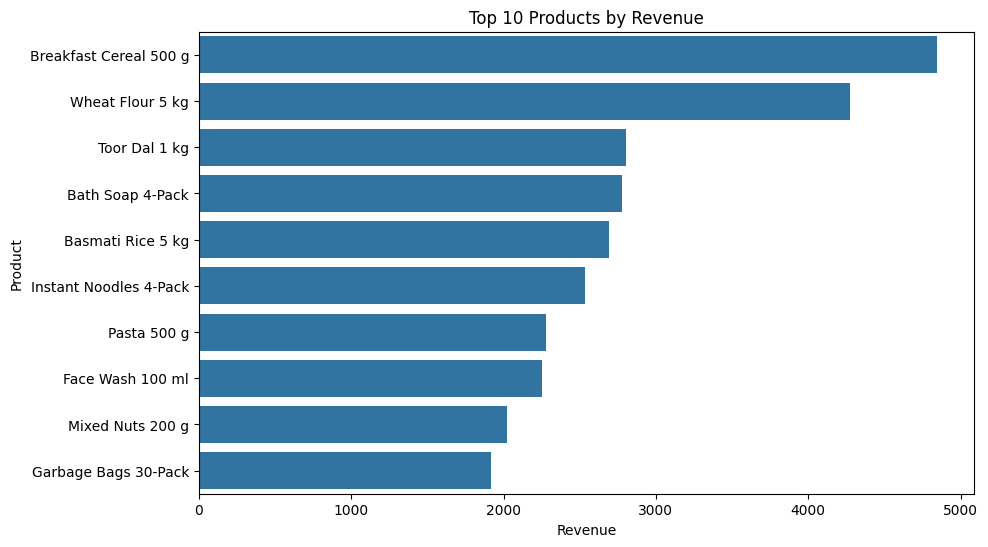

In [16]:
top_products = product_sales.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x="Total_Revenue",
    y="Product_Name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [17]:
category_sales = (
    product_sales.groupby("Category")
    .agg(
        Total_Revenue=("Total_Revenue", "sum"),
        Total_Units=("Total_Units", "sum"),
        Number_of_Products=("Product_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

display(category_sales)

,Category,Total_Revenue,Total_Units,Number_of_Products
5,Packaged Foods,10658,66,4
8,Staples & Grains,10190,46,4
6,Personal Care,7170,41,4
7,Snacks & Confectionery,4475,43,4
3,Home Care,4403,35,4
0,Beverages,4236,51,4
4,Household Essentials,3009,29,4
2,Fresh Produce,2423,55,4
1,Dairy & Breakfast,1848,28,4


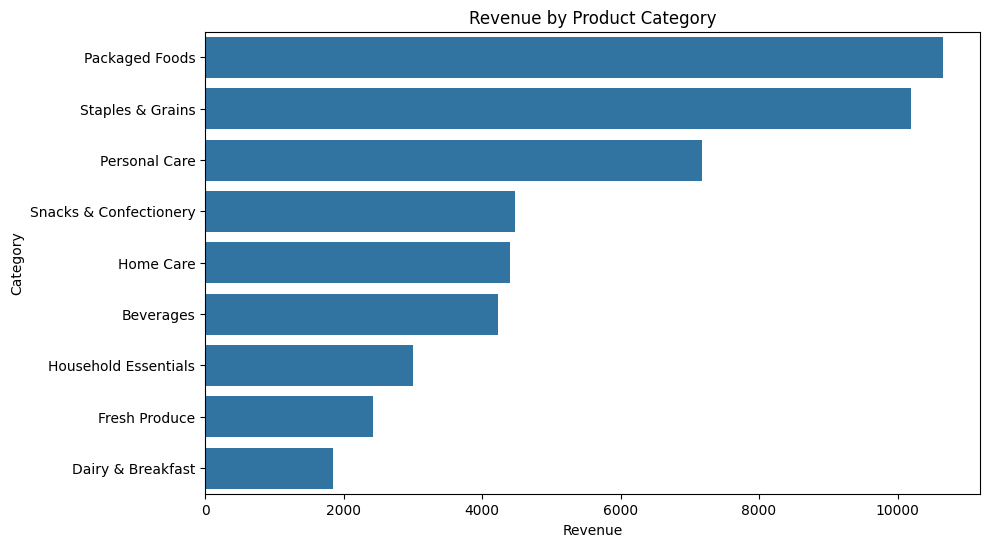

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales,
    x="Total_Revenue",
    y="Category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()


In [19]:
customer_sales = (
    orders.groupby("Customer_ID")
    .agg(
        Total_Spending=("Total_Amount", "sum"),
        Total_Orders=("Order_ID", "nunique"),
        Total_Units=("Quantity", "sum")
    )
    .reset_index()
)

customer_sales = customer_sales.merge(
    customers,
    on="Customer_ID",
    how="left"
)

customer_sales = customer_sales.sort_values(
    "Total_Spending",
    ascending=False
)

display(customer_sales.head(10))

,Customer_ID,Total_Spending,Total_Orders,Total_Units,City,Customer_Segment,Age,Signup_Date
25,C0050,2196,9,15,Nashik,Regular,44,2026-03-16
93,C0160,1762,3,6,Mumbai,Regular,49,2025-05-11
17,C0037,1556,7,12,Nagpur,Regular,47,2024-12-22
13,C0031,1384,8,12,Navi Mumbai,Regular,35,2023-08-12
108,C0182,1370,4,6,Mumbai,Premium,18,2025-07-22
63,C0110,1320,4,6,Aurangabad,Regular,28,2025-05-16
70,C0120,1230,3,5,Nashik,Regular,23,2024-12-14
61,C0106,1197,4,7,Mumbai,Regular,35,2024-08-19
83,C0140,1130,7,8,Nashik,Regular,26,2025-04-03
28,C0059,1117,7,7,Mumbai,Regular,36,2025-06-06


In [20]:
segment_analysis = (
    customer_sales.groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Revenue=("Total_Spending", "sum"),
        Orders=("Total_Orders", "sum")
    )
    .reset_index()
)

segment_analysis["Average_Spending"] = (
    segment_analysis["Revenue"] /
    segment_analysis["Customers"]
)

display(segment_analysis)

,Customer_Segment,Customers,Revenue,Orders,Average_Spending
0,Budget,31,8027,53,258.935484
1,Family,26,8667,45,333.346154
2,Premium,17,6496,43,382.117647
3,Regular,46,25222,138,548.304348


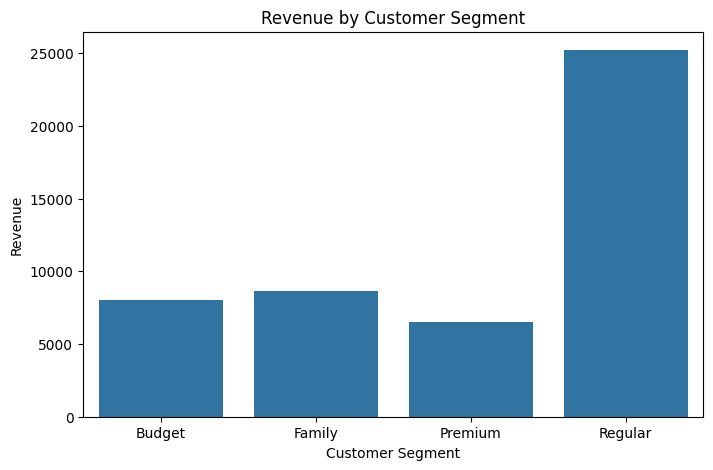

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_analysis,
    x="Customer_Segment",
    y="Revenue"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [22]:
interaction_counts = interactions["Interaction_Type"].value_counts()

display(interaction_counts)

Interaction_Type
View           2708
Add_to_Cart     945
Name: count, dtype: int64

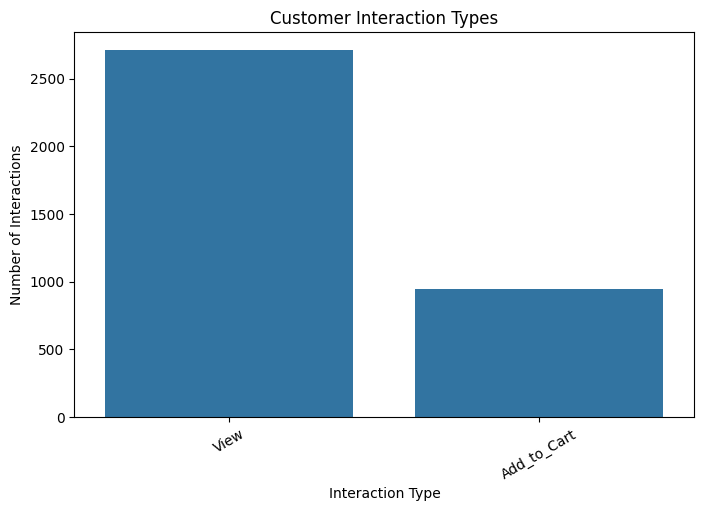

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=interactions,
    x="Interaction_Type"
)

plt.title("Customer Interaction Types")
plt.xlabel("Interaction Type")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=30)

plt.show()

In [24]:
product_interactions = (
    interactions.groupby("Product_ID")
    .agg(
        Total_Interactions=("Interaction_ID", "count"),
        Unique_Customers=("Customer_ID", "nunique")
    )
    .reset_index()
)

product_interactions = product_interactions.merge(
    products,
    on="Product_ID",
    how="left"
)

product_interactions = product_interactions.sort_values(
    "Total_Interactions",
    ascending=False
)

display(product_interactions.head(10))

,Product_ID,Total_Interactions,Unique_Customers,Product_Name,Category,Price
25,P026,254,129,Laundry Detergent 1 kg,Home Care,165
16,P017,239,105,Orange Juice 1 L,Beverages,115
12,P013,239,109,Instant Noodles 4-Pack,Packaged Foods,149
29,P030,180,90,Bath Soap 4-Pack,Personal Care,185
14,P015,161,74,Pasta 500 g,Packaged Foods,95
30,P031,138,63,Toothpaste 150 g,Personal Care,96
24,P025,131,71,Dishwash Liquid 500 ml,Home Care,89
21,P022,121,66,Mixed Nuts 200 g,Snacks & Confectionery,225
33,P034,121,62,Garbage Bags 30-Pack,Household Essentials,120
8,P009,118,69,Bananas 1 kg,Fresh Produce,55


In [25]:
product_performance = product_interactions.merge(
    product_sales[
        [
            "Product_ID",
            "Total_Units",
            "Total_Revenue",
            "Number_of_Orders"
        ]
    ],
    on="Product_ID",
    how="left"
)

product_performance[
    ["Total_Units", "Total_Revenue", "Number_of_Orders"]
] = product_performance[
    ["Total_Units", "Total_Revenue", "Number_of_Orders"]
].fillna(0)

display(product_performance.head())

,Product_ID,Total_Interactions,Unique_Customers,Product_Name,Category,Price,Total_Units,Total_Revenue,Number_of_Orders
0,P026,254,129,Laundry Detergent 1 kg,Home Care,165,6,990,4
1,P017,239,105,Orange Juice 1 L,Beverages,115,16,1840,12
2,P013,239,109,Instant Noodles 4-Pack,Packaged Foods,149,17,2533,11
3,P030,180,90,Bath Soap 4-Pack,Personal Care,185,15,2775,9
4,P015,161,74,Pasta 500 g,Packaged Foods,95,24,2280,14


In [26]:
product_performance["Conversion_Rate"] = (
    product_performance["Number_of_Orders"] /
    product_performance["Total_Interactions"]
) * 100

product_performance["Conversion_Rate"] = (
    product_performance["Conversion_Rate"].round(2)
)

display(
    product_performance.sort_values(
        "Total_Interactions",
        ascending=False
    ).head(10)
)

,Product_ID,Total_Interactions,Unique_Customers,Product_Name,Category,Price,Total_Units,Total_Revenue,Number_of_Orders,Conversion_Rate
0,P026,254,129,Laundry Detergent 1 kg,Home Care,165,6,990,4,1.57
1,P017,239,105,Orange Juice 1 L,Beverages,115,16,1840,12,5.02
2,P013,239,109,Instant Noodles 4-Pack,Packaged Foods,149,17,2533,11,4.60
3,P030,180,90,Bath Soap 4-Pack,Personal Care,185,15,2775,9,5.00
4,P015,161,74,Pasta 500 g,Packaged Foods,95,24,2280,14,8.70
5,P031,138,63,Toothpaste 150 g,Personal Care,96,13,1248,8,5.80
6,P025,131,71,Dishwash Liquid 500 ml,Home Care,89,12,1068,9,6.87
7,P022,121,66,Mixed Nuts 200 g,Snacks & Confectionery,225,9,2025,8,6.61
8,P034,121,62,Garbage Bags 30-Pack,Household Essentials,120,16,1920,12,9.92
9,P009,118,69,Bananas 1 kg,Fresh Produce,55,13,715,9,7.63


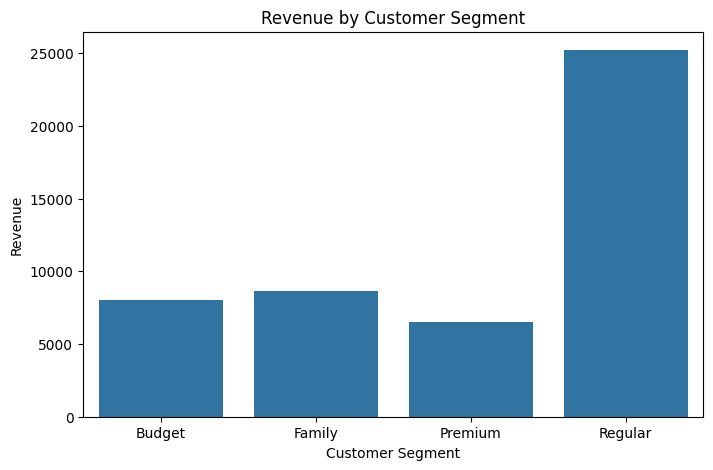

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_analysis,
    x="Customer_Segment",
    y="Revenue"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [28]:
high_interest_low_conversion = product_performance[
    (product_performance["Total_Interactions"] >=
     product_performance["Total_Interactions"].median()) &
    (product_performance["Conversion_Rate"] <
     product_performance["Conversion_Rate"].median())
]

high_interest_low_conversion = high_interest_low_conversion.sort_values(
    "Total_Interactions",
    ascending=False
)

display(high_interest_low_conversion)

,Product_ID,Total_Interactions,Unique_Customers,Product_Name,Category,Price,Total_Units,Total_Revenue,Number_of_Orders,Conversion_Rate
0,P026,254,129,Laundry Detergent 1 kg,Home Care,165,6,990,4,1.57
1,P017,239,105,Orange Juice 1 L,Beverages,115,16,1840,12,5.02
2,P013,239,109,Instant Noodles 4-Pack,Packaged Foods,149,17,2533,11,4.60
3,P030,180,90,Bath Soap 4-Pack,Personal Care,185,15,2775,9,5.00
5,P031,138,63,Toothpaste 150 g,Personal Care,96,13,1248,8,5.80
6,P025,131,71,Dishwash Liquid 500 ml,Home Care,89,12,1068,9,6.87
7,P022,121,66,Mixed Nuts 200 g,Snacks & Confectionery,225,9,2025,8,6.61
9,P009,118,69,Bananas 1 kg,Fresh Produce,55,13,715,9,7.63
10,P028,115,63,Paper Towels 6-Roll,Home Care,135,12,1620,9,7.83
12,P004,113,64,Butter 100 g,Dairy & Breakfast,62,11,682,7,6.19


In [29]:
inventory_summary = (
    inventory.groupby("Product_ID")
    .agg(
        Total_Units_Sold=("Units_Sold", "sum"),
        Total_Replenishment=("Replenishment_Units", "sum"),
        Current_Stock=("Closing_Stock", "last"),
        Average_Stock=("Closing_Stock", "mean")
    )
    .reset_index()
)

inventory_summary = inventory_summary.merge(
    products,
    on="Product_ID",
    how="left"
)

display(inventory_summary.head())

,Product_ID,Total_Units_Sold,Total_Replenishment,Current_Stock,Average_Stock,Product_Name,Category,Price
0,P001,7,6,10,10.290323,Toned Milk 1 L,Dairy & Breakfast,64
1,P002,6,6,15,14.516129,Paneer 200 g,Dairy & Breakfast,85
2,P003,4,3,10,10.677419,Curd 400 g,Dairy & Breakfast,52
3,P004,11,11,27,26.161290,Butter 100 g,Dairy & Breakfast,62
4,P005,6,6,11,10.225806,Basmati Rice 5 kg,Staples & Grains,449


In [31]:
inventory_status = (
    inventory.groupby(["Product_ID", "Stock_Status"])
    .size()
    .reset_index(name="Days")
)
display(inventory_status.head(20))

,Product_ID,Stock_Status,Days
0,P001,Low Stock,31
1,P002,Low Stock,31
2,P003,Low Stock,31
3,P004,Healthy,31
4,P005,Low Stock,31
5,P006,Healthy,31
6,P007,Healthy,31
7,P008,Healthy,31
8,P009,Healthy,31
9,P010,Healthy,31


In [32]:
inventory_summary["Recommendation"] = np.where(
    (inventory_summary["Current_Stock"] <= 10) &
    (inventory_summary["Total_Units_Sold"] > 20),
    "URGENT RESTOCK",

    np.where(
        inventory_summary["Current_Stock"] <= 10,
        "MONITOR STOCK",

        np.where(
            inventory_summary["Total_Units_Sold"] > 50,
            "HIGH DEMAND",
            "NORMAL"
        )
    )
)

display(
    inventory_summary[
        [
            "Product_ID",
            "Product_Name",
            "Current_Stock",
            "Total_Units_Sold",
            "Recommendation"
        ]
    ].sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

,Product_ID,Product_Name,Current_Stock,Total_Units_Sold,Recommendation
14,P015,Pasta 500 g,9,24,URGENT RESTOCK
11,P012,Potatoes 1 kg,14,23,NORMAL
17,P018,Cola 750 ml,12,21,NORMAL
6,P007,Toor Dal 1 kg,28,17,NORMAL
12,P013,Instant Noodles 4-Pack,4,17,MONITOR STOCK
13,P014,Breakfast Cereal 500 g,13,17,NORMAL
16,P017,Orange Juice 1 L,6,16,MONITOR STOCK
5,P006,Wheat Flour 5 kg,20,15,NORMAL
29,P030,Bath Soap 4-Pack,0,15,MONITOR STOCK
33,P034,Garbage Bags 30-Pack,22,15,NORMAL


In [33]:
final_product_analysis = product_performance.merge(
    inventory_summary[
        [
            "Product_ID",
            "Current_Stock",
            "Recommendation"
        ]
    ],
    on="Product_ID",
    how="left"
)

final_product_analysis = final_product_analysis[
    [
        "Product_ID",
        "Product_Name",
        "Category",
        "Total_Interactions",
        "Total_Units",
        "Total_Revenue",
        "Conversion_Rate",
        "Current_Stock",
        "Recommendation"
    ]
]

display(final_product_analysis.head(20))

,Product_ID,Product_Name,Category,Total_Interactions,Total_Units,Total_Revenue,Conversion_Rate,Current_Stock,Recommendation
0,P026,Laundry Detergent 1 kg,Home Care,254,6,990,1.57,10,MONITOR STOCK
1,P017,Orange Juice 1 L,Beverages,239,16,1840,5.02,6,MONITOR STOCK
2,P013,Instant Noodles 4-Pack,Packaged Foods,239,17,2533,4.60,4,MONITOR STOCK
3,P030,Bath Soap 4-Pack,Personal Care,180,15,2775,5.00,0,MONITOR STOCK
4,P015,Pasta 500 g,Packaged Foods,161,24,2280,8.70,9,URGENT RESTOCK
5,P031,Toothpaste 150 g,Personal Care,138,13,1248,5.80,11,NORMAL
6,P025,Dishwash Liquid 500 ml,Home Care,131,12,1068,6.87,8,MONITOR STOCK
7,P022,Mixed Nuts 200 g,Snacks & Confectionery,121,9,2025,6.61,11,NORMAL
8,P034,Garbage Bags 30-Pack,Household Essentials,121,16,1920,9.92,22,NORMAL
9,P009,Bananas 1 kg,Fresh Produce,118,13,715,7.63,30,NORMAL


In [34]:
top_product = product_sales.iloc[0]

top_category = category_sales.iloc[0]

top_customer = customer_sales.iloc[0]

urgent_products = inventory_summary[
    inventory_summary["Recommendation"] == "URGENT RESTOCK"
]

print("========== KEY BUSINESS INSIGHTS ==========\n")

print(
    f"🏆 Top Product: {top_product['Product_Name']} "
    f"generated ₹{top_product['Total_Revenue']:,.2f} revenue."
)

print(
    f"📦 Top Category: {top_category['Category']} "
    f"generated ₹{top_category['Total_Revenue']:,.2f} revenue."
)

print(
    f"👤 Highest Spending Customer: {top_customer['Customer_ID']} "
    f"spent ₹{top_customer['Total_Spending']:,.2f}."
)

print(
    f"🚨 Products requiring urgent restocking: "
    f"{len(urgent_products)}"
)

print(
    f"📊 Average Order Value: ₹{average_order_value:,.2f}"
)

========== KEY BUSINESS INSIGHTS ==========

🏆 Top Product: Breakfast Cereal 500 g generated ₹4,845.00 revenue.
📦 Top Category: Packaged Foods generated ₹10,658.00 revenue.
👤 Highest Spending Customer: C0050 spent ₹2,196.00.
🚨 Products requiring urgent restocking: 1
📊 Average Order Value: ₹173.52
